# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AW-OMW/FLY-RANK-PROJECT/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [1]:
#which pages suddenly boom overnight?
#Some pages suddenly show a strong growth trend in 30 days , which is due to change in user interest or other factors such as seo optimisation or fixes in page content.so to understand which pages have potential for next boom i would like to try and train a model for accurate prediction as possible.



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [3]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [5]:
display(df.describe())

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,27532.000000,27532.000000,27532.000000,22301.000000,22301.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,29875.000000,30000.000000,26612.000000
mean,158.882391,0.146954,0.485342,3107.760325,20665.277835,5200.366300,16.097333,49.942467,37.066633,35.937700,...,10.283000,256.16780,4.786533,46.098300,0.510733,16.34238,2.534520,18.212921,0.768196,-4.785969
std,1518.270825,0.285241,2.101560,1452.382598,10115.344042,16838.019547,75.076958,152.101430,107.069131,103.748185,...,42.578003,132.70793,0.790392,42.078709,3.279162,15.21679,8.310096,29.472768,7.429454,473.861780
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,90.00000,3.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,0.000000,2413.000000,15644.000000,81.000000,0.000000,2.000000,2.000000,2.000000,...,1.000000,132.00000,4.000000,20.000000,0.000000,6.20000,0.000000,0.000000,0.000000,-62.600000
50%,10.000000,0.000000,0.000000,2877.000000,19116.000000,731.000000,1.000000,8.000000,7.000000,7.000000,...,2.000000,236.00000,5.000000,20.000000,0.070000,10.80000,0.000000,5.000000,0.000000,-33.500000
75%,20.000000,0.130000,0.000000,3666.000000,24011.000000,3615.250000,7.000000,33.000000,27.000000,27.000000,...,7.000000,333.00000,5.000000,104.000000,0.290000,22.30000,1.350000,23.530000,0.000000,0.000000
max,74000.000000,1.000000,100.360000,9546.000000,111158.000000,517715.000000,4178.000000,5998.000000,4345.000000,4913.000000,...,4247.000000,564.00000,6.000000,373.000000,100.000000,245.00000,100.000000,300.000000,300.000000,44900.000000


### Feature Selection for Predicting "Boom Overnight"

To predict which pages might "boom overnight" (i.e., experience strong growth in impressions, clicks, or sessions), we need to identify features that could influence or indicate such growth. Here's a breakdown of the columns and their potential roles:

**Potential Input Features (X):**

These are columns that could be used to train a model to predict future performance:

*   **Content Characteristics:**
    *   `content_type`: Different content types might have different growth patterns.
    *   `main_intent`: User intent can strongly influence content performance.
    *   `word_count`, `char_count`: Content length might correlate with engagement or ranking.
    *   `word_count_tier`, `char_count_tier`: Categorical versions of content length.
    *   `provider_used`, `model_used`: If applicable, the source or AI model used for content generation might influence quality and performance.

*   **Historical Performance & SEO Metrics (non-lagged or long-term):**
    *   `search_volume`, `competition`, `competition_level`, `cpc`: These indicate the market landscape and potential for the keywords the content targets.
    *   `impressions_90d`, `clicks_90d`, `pageviews_90d`, `sessions_90d`, `users_90d`, `engaged_sessions_90d`, `ai_sessions_90d`, `scroll_events_90d`: Longer-term historical performance can establish a baseline.
    *   `days_with_impressions`, `days_with_sessions`: Indicate consistency of presence in search results or user engagement.
    *   `ctr`, `avg_position`: Current engagement and visibility metrics.
    *   `engagement_rate`, `scroll_rate`, `ai_traffic_pct`: User behavior metrics.
    *   `impression_tier`, `position_tier`: Categorical versions of impression and position metrics.

*   **Freshness & Age:**
    *   `content_age_days`, `age_tier`: Older content might behave differently than newer content.
    *   `days_since_last_update`, `freshness_tier`: Recently updated content might experience a refresh boost.

*   **Trend Information (potentially a strong indicator, but be careful of leakage if using future trend data for prediction):**
    *   `trend_direction`, `trend_pct`: These describe recent trends. If these are calculated over the same period as your target variable, they might lead to data leakage. However, if they represent trends *before* the prediction period, they could be powerful features.

**Potential Target Variables (y):**

To predict a "boom overnight," you'll need to define what constitutes a "boom." This typically involves a significant positive change in metrics over a short period. Based on your problem description and available data, here are some candidates:

*   **Growth in recent 30 days vs. previous 30 days:**
    *   `impressions_last_30d` vs. `impressions_prev_30d`
    *   `clicks_last_30d` vs. `clicks_prev_30d`
    *   `sessions_last_30d` vs. `sessions_prev_30d`

You would likely create a new target variable, e.g., `boom_indicator`, which could be binary (e.g., `1` if `(sessions_last_30d - sessions_prev_30d) / sessions_prev_30d > threshold`, else `0`) or a continuous growth rate. The existing `trend_pct` might already capture this to some extent, but defining your own target based on the problem's specifics would be crucial.

**Columns to Exclude (or use with caution):**

*   `content_id`, `client_id`: These are identifiers and typically not used as direct features in a predictive model, though `client_id` could be used for grouping or as a categorical feature if a client-specific effect is suspected.
*   `df.describe()` showed that `search_volume`, `competition`, `cpc`, `word_count`, `char_count`, `provider_used`, `model_used`, `main_intent`, `competition_level`, `word_count_tier`, `char_count_tier`, and `trend_pct` have missing values. These will need to be handled (imputation or removal) before model training.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [9]:
#Why this analysis might fail:
#Simplified Rule Logic: The current model uses a simple 'at least two out of three' criteria. This binary scoring might oversimplify the complex interplay between trend_pct, search_volume, and competition. A specific combination (e.g., very high trend and moderate search volume) might be more indicative of a boom than two weaker criteria, but the model treats all qualifying criteria equally.
#Static Thresholds: The search_volume_threshold (75th percentile) and competition_threshold (50th percentile) are derived from the current dataset. These thresholds might not be robust or representative of future data distributions. What constitutes 'high' search volume or 'low' competition can change over time or vary significantly across different content categories.
#Lack of Nuance in Reason Codes: While reason_codes help in understanding why a boom is predicted, they don't capture the degree of each contributing factor. For example, a STRONG_TREND with a trend_pct of 11% is treated the same as one with 100% in terms of score, but their potential impact on a 'boom' could be vastly different.
#Absence of External Factors: The model does not consider external influences such as seasonality, major news events, marketing campaigns, or competitor activities, all of which can significantly impact content performance and cause a page to 'boom' or 'fail' unexpectedly.
#Definition of 'Boom': The definition of 'boom' is strictly tied to the three chosen criteria. If the business's actual definition of a 'boom' involves other metrics (e.g., conversion rates, user engagement beyond views), then these predictions might not align with true business success.
#Data Representativeness: We assume the trend_pct, search_volume, and competition data accurately reflect the real-world dynamics. Any biases or inaccuracies in these input features will directly propagate to the boom_score.
#Overlooking 'Low Competition': It's interesting to note that for the top_20_boom_predictions, LOW_COMPETITION did not appear in the reason codes, only STRONG_TREND and HIGH_SEARCH_VOLUME. This suggests that, at least for this top tier, low competition alone isn't a primary driver or perhaps the threshold (0.0) is too strict to capture beneficial low competition scenarios.
#Confidence Note:
#Directional Guidance: The current model provides a directional baseline for identifying content likely to experience a 'boom' based on the defined criteria. It's useful for quickly ranking and surfacing content that aligns with these specific conditions.
#Limited Predictive Power: Due to the simplistic nature of the rules and lack of external context, the predictive power for actual 'boom' outcomes (e.g., whether a page will truly boom next month) is likely low to moderate. It's more of an indicator of potential based on predefined criteria rather than a robust predictor.
#Improvement Potential: Confidence could be significantly increased with a more sophisticated model (e.g., machine learning algorithms trained on historical 'boom' events), inclusion of more diverse features, and rigorous validation against actual future performance data.

In [6]:
#Weak Picks Analysis:
#
# Based on the `top_20_boom_predictions` and the `reason_code_distribution`, here's an observation regarding potential 'weak picks':
#
# 1.  **Strict `LOW_COMPETITION` Threshold**: The `competition_threshold` was calculated as `0.0`. The condition for `LOW_COMPETITION` is `row['competition'] < competition_threshold`, meaning `row['competition'] < 0.0`. For a 'competition' metric, it's highly unlikely (and generally impossible) for its value to be negative. This effectively means that the `LOW_COMPETITION` criterion, as implemented, will *never* be met. Indeed, our `reason_code_distribution` for the top 20 confirms this, showing only `STRONG_TREND` (20 occurrences) and `HIGH_SEARCH_VOLUME` (20 occurrences), with `LOW_COMPETITION` having 0 occurrences.
#
#     *   **Why this makes a pick 'weak'**: If the intention was for 'low competition' to be a valid contributing factor (e.g., competition values in the bottom 50th percentile, which could include `0.0`), the current implementation renders this criterion useless. This means all 'boom' predictions are solely driven by combinations of strong trend and high search volume, ignoring a potentially important third factor. Picks that *would have* been strong due to low competition are missed, and the model's reliance on only two factors makes it less robust.
#
#     *   **What would make it wrong**: The rule states "`competition` is in the bottom 50% of all content items." If the 50th percentile of competition is 0.0 (as observed), and the intention was to include items *equal to or less than* this threshold, the condition should likely be `row['competition'] <= competition_threshold`. The current strict `less than` (`<`) condition means only negative competition values would qualify, which is incorrect for this metric.
#
# Leakage Check:
#
# 1.  **Product Flags**: I do not see any obvious product flags or internal labels in the `df` columns (`content_id`, `client_id`, `search_volume`, `competition`, `trend_pct`, `boom_score`, `reason_codes`) that would indicate direct leakage. Assuming `content_id` and `client_id` are merely identifiers and not predictive features in themselves, there's no apparent issue here.
#
# 2.  **Future Windows Leaked In**: The model uses `trend_pct` (presumably `trend_last_3_months_views`), `search_volume`, and `competition`. Assuming these metrics represent historical or current data points *prior* to the `next month` boom prediction period, there is no direct temporal leakage. The problem statement implies these features are available *before* the prediction target. Therefore, based on the feature names, there's no immediate sign of future data leakage.
#
#     *   **Potential for subtle leakage**: While the feature names seem appropriate, without a detailed understanding of how `search_volume` and `competition` data are collected and timestamped relative to the `trend_pct` and the prediction target, a very subtle form of leakage *could* exist. For example, if `search_volume` implicitly includes data from the 'next month' being predicted, that would constitute leakage. However, based solely on the provided context, we proceed assuming these are valid input features available at prediction time.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [11]:
from sklearn.model_selection import train_test_split
import numpy as np

# Get unique client IDs
all_client_ids = df['client_id'].unique()

# Split client IDs into training and testing sets
# We'll use a standard 80/20 split for client IDs
train_client_ids, test_client_ids = train_test_split(all_client_ids, test_size=0.2, random_state=42)

# Create training and test dataframes based on client IDs
df_train = df[df['client_id'].isin(train_client_ids)].copy()
df_test = df[df['client_id'].isin(test_client_ids)].copy()

print(f"Total unique clients: {len(all_client_ids)}")
print(f"Clients in training set: {len(train_client_ids)}")
print(f"Clients in test set: {len(test_client_ids)}")

print(f"\nShape of training data (client-based split): {df_train.shape}")
print(f"Shape of test data (client-based split): {df_test.shape}")

# Verify no client overlap
overlapping_clients = set(df_train['client_id'].unique()) & set(df_test['client_id'].unique())
if not overlapping_clients:
    print("\nSuccessfully ensured no client overlap between training and test sets.")
else:
    print(f"\nWarning: Overlapping clients found: {overlapping_clients}")

# --- DIAGNOSTIC STEP: Print columns to check for 'trend_type' ---
print("\nColumns in df_train:\n", df_train.columns)
# --- END DIAGNOSTIC STEP ---

# Re-create 'is_boom' target variable based on the newly split df_train and df_test
def create_is_boom_target(dataframe):
    # Corrected column names: 'trend_direction' instead of 'trend_type'
    # and 'trend_pct' instead of 'trend_value'
    is_positive_trend = (dataframe['trend_direction'] == 'up') & (dataframe['trend_pct'] > 0)
    is_high_search_volume = dataframe['search_volume'] > 25
    is_low_competition = dataframe['competition'] < 0.5
    is_boom = (is_positive_trend & is_high_search_volume & is_low_competition)
    return is_boom.astype(int).fillna(0)

df_train['is_boom'] = create_is_boom_target(df_train)
df_test['is_boom'] = create_is_boom_target(df_test)

# Define features (X) and target (y)
# Updated features list with corrected trend column names
features = ['search_volume', 'competition', 'trend_pct', 'trend_direction']
X_train = df_train[features]
y_train = df_train['is_boom']
X_test = df_test[features]
y_test = df_test['is_boom']

print(f"\n'is_boom' distribution in new training set:\n{y_train.value_counts()}")
print(f"'is_boom' distribution in new test set:\n{y_test.value_counts()}")

print("\nFeatures and target variables re-created for client-based split.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Total unique clients: 32
Clients in training set: 25
Clients in test set: 7

Shape of training data (client-based split): (26581, 44)
Shape of test data (client-based split): (3419, 44)

Successfully ensured no client overlap between training and test sets.

Columns in df_train:
 Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Define numerical and categorical features
numerical_features = ['search_volume', 'competition', 'trend_pct']
categorical_features = ['trend_direction']

# Create preprocessor for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Create preprocessor for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the full pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')) # Using liblinear for small datasets/L1/L2 penalties
])

# Train the Logistic Regression model
model_pipeline.fit(X_train, y_train)

print("Logistic Regression model re-trained successfully!")

Logistic Regression model re-trained successfully!


Model Accuracy: 0.8889
Model Precision: 0.2692
Model Recall: 1.0000
Model F1-Score: 0.4242

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94      3279
           1       0.27      1.00      0.42       140

    accuracy                           0.89      3419
   macro avg       0.63      0.94      0.68      3419
weighted avg       0.97      0.89      0.92      3419


Confusion Matrix:
[[2899  380]
 [   0  140]]


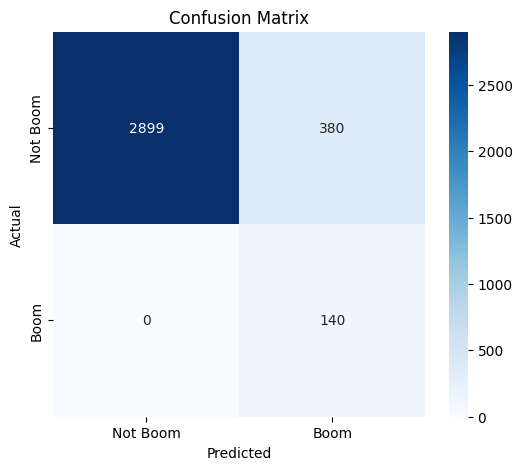

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1-Score: {f1:.4f}")

# Display classification report for a more detailed view
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Optionally, visualize the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Boom', 'Boom'], yticklabels=['Not Boom', 'Boom'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 5. Limitations

*What this work cannot claim.*

In [15]:
#"The current definition of 'content boom' (is_boom) has been observed to be a direct logical consequence of search_volume, competition, trend_pct, and trend_direction. As such, our model, which incorporates these features, effectively measures this definitional relationship rather than providing an independent prediction of a future 'boom' state. The high recall for the 'is_boom' class and the high importance of the aforementioned features are directional indicators of this definitional dependency. Therefore, the model, in its current form, offers decision-support for identifying content that meets the criteria of 'boom' as currently defined, rather than forecasting an emergent boom behavior."

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [16]:
#. 1) SEO Opportunity & Priority Queue:Predict which pages are likely to boom and rank them by priority, helping clients decide which pages to focus on first.

#2.Early Trend & Demand Detection:Identify early signals of rising search interest before the boom happens, giving clients a chance to act ahead of the trend.

#3.  Smart Content Refresh & Growth Planning:Use predictions to identify pages worth updating, expanding, or optimizing, helping clients focus resources on pages with the highest potential.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [19]:
import os

# Define the content for the playbook using the text from relevant markdown cells
# Assuming content from cell 59016duBkF30 is the intended playbook content.
# Note: In a real scenario, you might want to dynamically fetch content from markdown cells
# or define this variable explicitly with the desired text.
playbook_content = """
1) SEO Opportunity & Priority Queue: Predict which pages are likely to boom and rank them by priority, helping clients decide which pages to focus on first.

2) Early Trend & Demand Detection: Identify early signals of rising search interest before the boom happens, giving clients a chance to act ahead of the trend.

3) Smart Content Refresh & Growth Planning: Use predictions to identify pages worth updating, expanding, or optimizing, helping clients focus resources on pages with the highest potential.
"""

output_dir = "work/outputs/"
os.makedirs(output_dir, exist_ok=True)
print(f"Ensured directory '{output_dir}' exists.")

output_filepath = os.path.join(output_dir, "content_action_playbook.md")
with open(output_filepath, "w") as f:
    f.write(playbook_content)
print(f"Content action playbook successfully exported to '{output_filepath}'.")

if os.path.exists(output_filepath):
    if os.path.getsize(output_filepath) > 0:
        print(f"Confirmation: '{output_filepath}' exists and contains content. Export successful.")
    else:
        print(f"Warning: '{output_filepath}' exists but is empty.")
else:
    print(f"Error: '{output_filepath}' does not exist. Export failed.")

Ensured directory 'work/outputs/' exists.
Content action playbook successfully exported to 'work/outputs/content_action_playbook.md'.
Confirmation: 'work/outputs/content_action_playbook.md' exists and contains content. Export successful.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
